Run this notebook to reproduce **fig. 1**

note: for privacy reasons age can be published just as a cathegory so the graph might not be the same as in the paper

In [1]:
import os,sys
%matplotlib inline
import matplotlib.pylab as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from venny4py.venny4py import *
from PyComplexHeatmap import *
from utils.helper_classification import *

In [2]:
df = pd.read_csv("data/rwd.csv")
outcomes = pd.read_csv("data/outcomes.csv")
df = pd.merge(df, outcomes, on="Subject", suffixes=('', '_y'))
genomics = pd.read_csv("data/genomics.csv")
df = pd.merge(df, genomics, on="Subject", how="left", suffixes=('', '_y'))

In [19]:
outcome = 'DCR'
rwd = df.copy()
center_order = ['INT','GHD','VHIO','SZMC','MH','UOC']

df_sorted = rwd.sort_values(by=[outcome, 'CENTER'], ascending=[False, True])\
               .reset_index(drop=True)

In [20]:
#create a column 'SMOKING_STATUS' based on the values in SMOKING CURRENT,SMOKING FORMER,SMOKING NEVER
df_sorted['SMOKING_STATUS'] = np.where(df_sorted['SMOKING CURRENT'] == 1, 'Current',
                                       np.where(df_sorted['SMOKING FORMER'] == 1, 'Former',
                                                np.where(df_sorted['SMOKING NEVER'] == 1, 'Never', '')))
df_sorted.dropna(subset=outcome,inplace=True)
df_sorted[outcome].isna().sum()

0

In [21]:
# 1) Grab the original Blues colormap:
orig = plt.cm.Blues

# 2) Define a helper to truncate any colormap between minval and maxval:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Returns a new LinearSegmentedColormap by sampling `cmap` from 
    minval to maxval (both between 0 and 1). `n` is the number of discrete colors.
    """
    new_cmap = LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# 3) Create a truncated version starting at 0.3 (i.e., skipping the very lightest blues):
trunc = truncate_colormap(orig, minval=0.55, maxval=1.0)
trunc_pdl1 = truncate_colormap(plt.cm.Greens, minval=0.4, maxval=1.0)
trunc_ecog = truncate_colormap(plt.cm.OrRd, minval=0.3, maxval=1.0)

In [22]:
df_sorted[outcome] = df_sorted[outcome].astype(str)
df_sorted[outcome] = df_sorted[outcome].map({'0.0': 'Non Responders', '1.0': 'Responders'})
df_sorted['OS 6'] = df_sorted['OS_6'].astype(str)
df_sorted['OS 6'] = df_sorted['OS 6'].map({'0.0': '< 6 months', '1.0': '≥ 6 months', 'nan': ''})
df_sorted['OS 24'] = df_sorted['OS_24'].astype(str)
df_sorted['OS 24'] = df_sorted['OS 24'].map({'0.0': '< 24 months', '1.0': '≥ 24 months', 'nan': ''})
df_sorted['IO IOCHT'] = df_sorted['IO IOCHT'].map({0: 'Immuno', 1: 'Immuno + Chemo'})
df_sorted['HISTOLOGY SQUAMOUS'] = df_sorted['HISTOLOGY SQUAMOUS'].map({0: 'No Squamous', 1: 'Squamous', np.nan: ''})
df_sorted['PDL1 CATEGORY'] = df_sorted['PDL1 CATEGORY'].map({0: '< 1%', 1: '1-49%', 2: '≥ 50%', np.nan: ''})
df_sorted['AGE AT IO START'] = df_sorted['AGE AT IO START'].map({'nan': '', '<62':'<62', '62-69':'62-69', '>69':'>69'})

In [23]:
#map genomics
df_sorted['KRAS'] = df_sorted['KRAS'].map({0: 'No Mutated', 1: 'Mutated'})
df_sorted['P53'] = df_sorted['P53'].map({0: 'No Mutated', 1: 'Mutated'})
df_sorted['STK11'] = df_sorted['STK11'].map({0: 'No Mutated', 1: 'Mutated'})
df_sorted['DRIVER'] = df_sorted['DRIVER'].map({0: 'No Mutated', 1: 'Mutated'})

Starting plotting HeatmapAnnotations


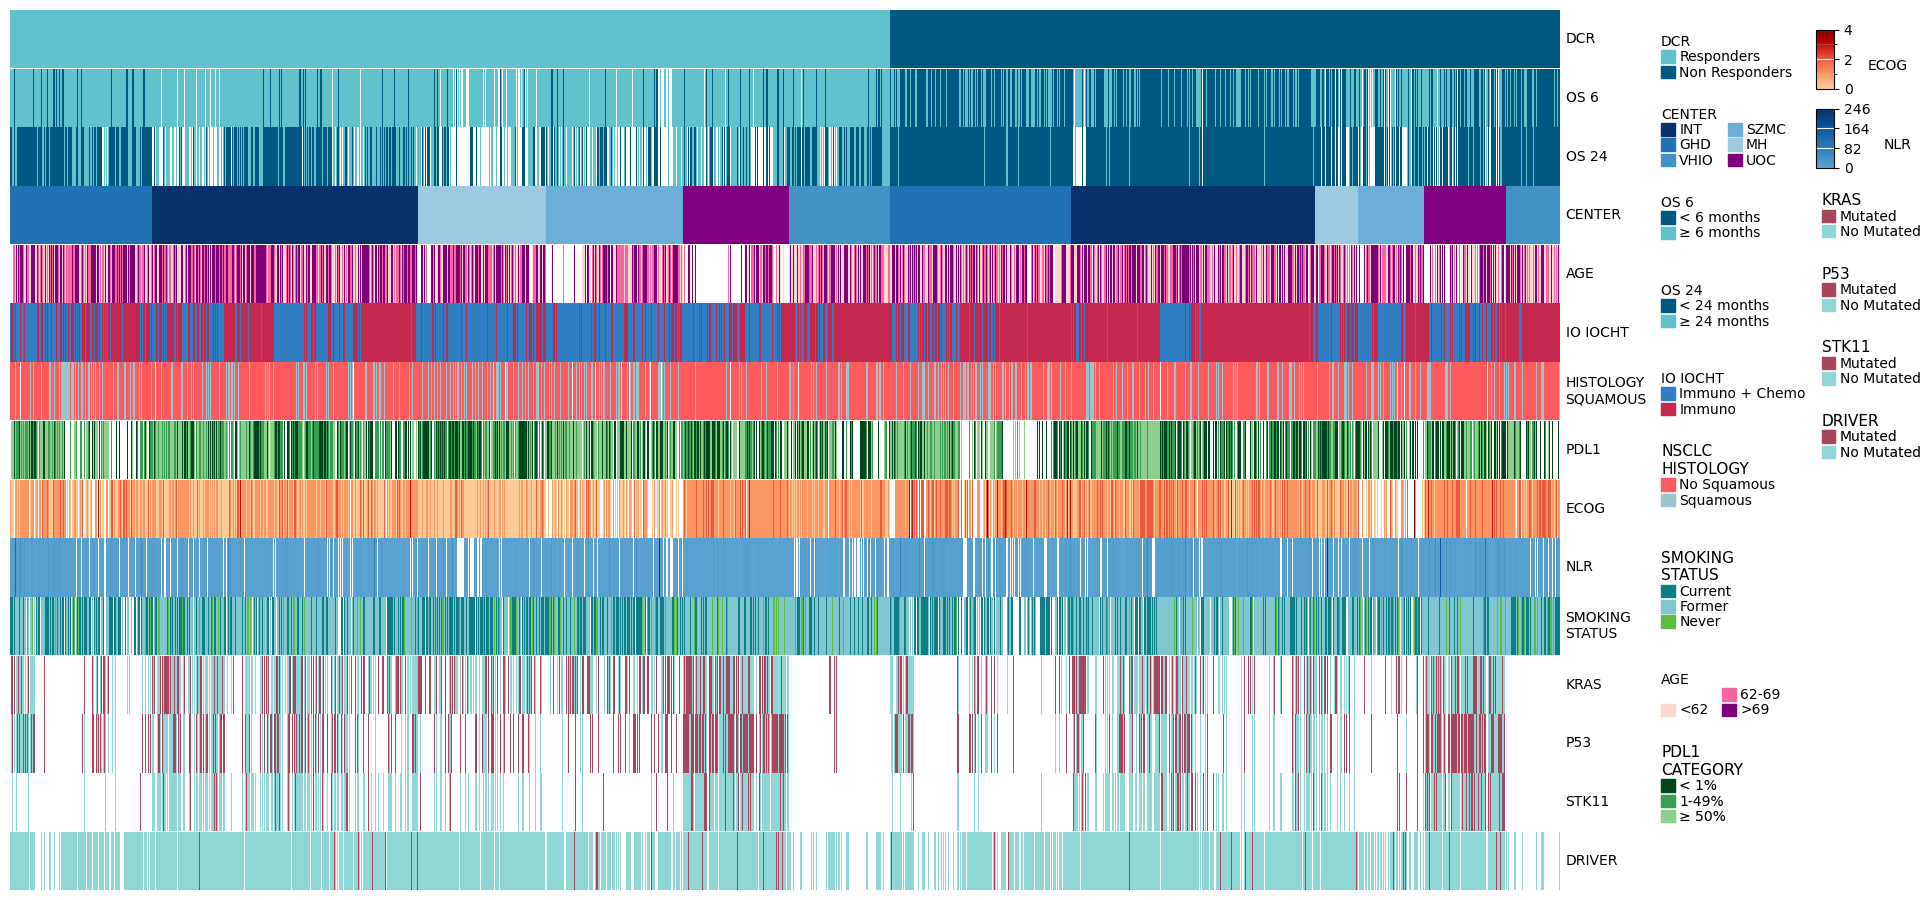

In [ ]:
plt.figure(figsize=(20, 10))
unique_values = df_sorted[outcome].unique()
DCR_color = {val: '#005780' if val == 'Non Responders' else '#60C2CD' for val in unique_values}
OS6_color = {
    '< 6 months': '#005780',
    '≥ 6 months': '#60C2CD',
    '': "#FFFFFF"}
OS24_color = {
    '< 24 months': '#005780',
    '≥ 24 months': '#60C2CD',
    '': "#FFFFFF"
}

center_color = {
    'INT':'#08306B',
    'GHD':'#2171B5',
    'VHIO':'#4292C6',
    'SZMC':'#6BAED6',
    'MH':'#9ECAE1',
    'UOC' : '#800080'
}
smoking_colors_full = {
    'Current': '#0d7d87',
    'Former': "#7fc6cf",
    'Never': "#5ABC42",
    '': "#FFFFFF" 
}
genomics_colors = {
    'Mutated': '#A7455D',  
    'No Mutated': '#8fd7d7',
}
pdl1_colors = {
    '< 1%': '#00461c',
    '1-49%': '#369f54',
    '≥ 50%': '#8ed08b',
    '': "#FFFFFF"  
}
histology_colors = {
    'No Squamous': '#FF5A5E',
    'Squamous': '#99C6CC',
    '': "#FFFFFF"  
}
age_colors = {
   '': "#FFFFFF",
   '<62': '#ffd5d1', 
   '62-69': '#f666a1', 
   '>69': '#7d0177'
}

col_ha = HeatmapAnnotation(

    DCR = anno_simple(df_sorted[outcome], add_text=False, label='DCR',legend_kws=dict(edgecolor = 'white',labelcolor='black',color_text=False), 
                    legend=True,  colors=DCR_color),
    OS_6=anno_simple(df_sorted['OS 6'], add_text=False, label='OS 6', legend_kws=dict(edgecolor = 'white',labelcolor='black',color_text=False), 
                    legend=True,  colors=OS6_color),
    OS_24=anno_simple(df_sorted['OS 24'], add_text=False, label='OS 24',
                    legend_kws=dict(edgecolor = 'white',labelcolor='black',color_text=False), 
                    legend=True,  colors=OS24_color),
    CENTER=anno_simple(df_sorted['CENTER'], add_text=False,
                       legend_kws=dict(edgecolor = 'white',labelcolor='black',color_text=False, ncol=2),
                         legend=True, colors=center_color), 
    AGE =anno_simple(df_sorted['AGE AT IO START'], add_text=False, legend_kws=dict(edgecolor = 'white',labelcolor='black',color_text=False, ncol=2),
                         legend=True, colors =age_colors),
    IO_IOCT = anno_simple(df_sorted['IO IOCHT'], add_text=False, label='IO IOCHT',
                          legend_kws=dict(edgecolor = 'white',labelcolor='black',color_text=False),
                            legend=True,  colors=['#317EC2', "#C5284F"]),
    NSCLC_HISTOLOGY_SQUAMOUS = anno_simple(df_sorted['HISTOLOGY SQUAMOUS'], add_text=False, 
                                           legend=True, colors=histology_colors, 
                                           label='HISTOLOGY\nSQUAMOUS', 
                                           legend_kws=dict(title= 'NSCLC\nHISTOLOGY', edgecolor = 'white',labelcolor='black',color_text=False, 
                                                           title_fontsize=11, alignment='left', frameon=True)),
    PDL1=anno_simple(df_sorted['PDL1 CATEGORY'], add_text=False, legend=True, colors=pdl1_colors, legend_kws=dict(title= 'PDL1\nCATEGORY', edgecolor = 'white',labelcolor='black',color_text=False, 
                                                           title_fontsize=11, alignment='left', frameon=True)),
    ECOG = anno_simple(df_sorted['ECOG PS'], add_text=False, legend=True, cmap=trunc_ecog), #'OrRd'
    NLR = anno_simple(df_sorted['NLR'], add_text=False, legend=True, cmap=trunc),
    SMOKING_STATUS= anno_simple(
        df_sorted['SMOKING_STATUS'],
        add_text=False,
        legend=True,
        colors=smoking_colors_full,
        label='SMOKING\nSTATUS',
        legend_kws=dict(title= 'SMOKING\nSTATUS', edgecolor = 'white',labelcolor='black',color_text=False, 
                        title_fontsize=11, alignment='left', frameon=True)
    ),
    KRAS = anno_simple(
        df_sorted['KRAS'],
        add_text=False,
        legend=True,
        colors=genomics_colors,
        label='KRAS',
        legend_kws=dict(title= 'KRAS', edgecolor = 'white',labelcolor='black',color_text=False, 
                        title_fontsize=11, alignment='left', frameon=True)
    ),
    P53 = anno_simple(
        df_sorted['P53'],
        add_text=False,
        legend=True,
        colors=genomics_colors,
        label='P53',
        legend_kws=dict(title= 'P53', edgecolor = 'white',labelcolor='black',color_text=False, 
                        title_fontsize=11, alignment='left', frameon=True)
    ),
    STK11 = anno_simple(
        df_sorted['STK11'],
        add_text=False,
        legend=True,
        colors=genomics_colors,
        label='STK11',
        legend_kws=dict(title= 'STK11', edgecolor = 'white',labelcolor='black',color_text=False, 
                        title_fontsize=11, alignment='left', frameon=True)
    ),
    DRIVER = anno_simple(
        df_sorted['DRIVER'],
        add_text=False,
        legend=True,
        colors=genomics_colors,
        label='DRIVER',
        legend_kws=dict(title= 'DRIVER', edgecolor = 'white',labelcolor='black',color_text=False, 
                        title_fontsize=11, alignment='left', frameon=True)
    ),
     axis=1,
    plot=True,
    plot_legend=True,
    legend_order=['DCR', 'CENTER', 'OS 6', 'OS 24','IO IOCHT','HISTOLOGY\nSQUAMOUS',
                  'SMOKING\nSTATUS', 'AGE', 'PDL1', 'ECOG', 'NLR',
                  'KRAS', 'P53', 'STK11', 'DRIVER'],
    legend_kws=dict(
        handlelength=1.5,
        handletextpad=0.5,
        ncol=2,                
        fontsize=9,
        edgecolor='white',
        labelcolor='black',
        color_text=False,
        columnspacing=2.0,
        loc='upper center',    
        bbox_to_anchor=(0.5, 0.02)  
    )
)


cbars = [c for c in col_ha.cbars if hasattr(c, 'ax')]
# ECOG colorbar (if available)
cbar_ecog = cbars[0] if len(cbars) > 0 else None
if cbar_ecog is not None:
    cbar_ecog.ax.set_ylabel('ECOG', rotation=0, labelpad=25)
    cbar_ecog.ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    cbar_ecog.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    # For the minor ticks: automatically place them between the major ones.
    cbar_ecog.ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    # Style the minor grid lines
    cbar_ecog.ax.grid(which='minor', axis='y', linestyle=':', color='lightgray', alpha=0.7, linewidth=0.5)
    cbar_ecog.ax.tick_params(axis='y', labelsize=10) # Control font size
    cbar_ecog.ax.grid(which='major', axis='y', linestyle='-', color='white', linewidth=0.8)

# NLR colorbar (if available)
cbar_nlr = cbars[1] if len(cbars) > 1 else None
if cbar_nlr is not None:
    cbar_nlr.ax.set_ylabel('NLR', rotation=0, labelpad=20)
    cbar_nlr.ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=4)) # Force 4 evenly spaced ticks
    cbar_nlr.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f')) # This makes it an integer
    cbar_nlr.ax.tick_params(axis='y', labelsize=10) # Control font size
    cbar_nlr.ax.grid(which='major', axis='y', linestyle='-', color='white', linewidth=0.8)

plt.show()

## Venn diagrams


In [2]:
rwd = pd.read_csv('data/rwd.csv')
radiomics = pd.read_csv('data/fmrad.csv')
dp = pd.read_csv('data/digital_pathology.csv')
genomics = pd.read_csv('data/genomics.csv')

<Figure size 1200x1200 with 0 Axes>

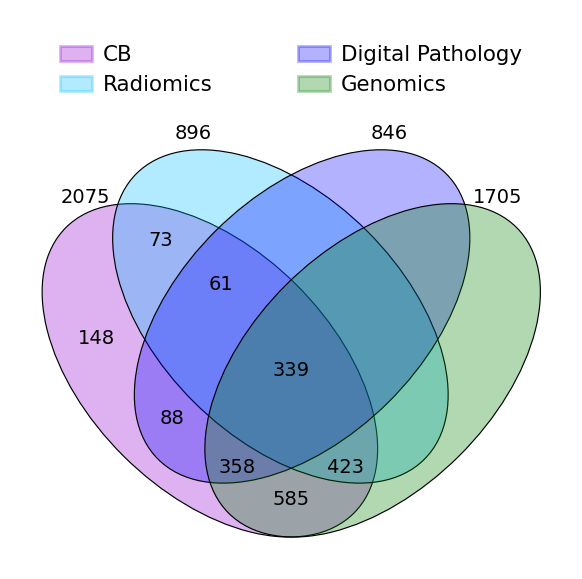

In [ ]:
genomics = genomics.dropna(subset=['DRIVER', 'KRAS', 'P53', 'STK11'], how='all')
#dict of sets
sets = {
    'CB': set(rwd['Subject']),
    'Radiomics': set(   radiomics[radiomics['Subject'].isin(rwd['Subject'])]['Subject']),
    'Digital Pathology': set(dp[dp['Subject'].isin(rwd['Subject'])]['Subject']),
    'Genomics': set(genomics['Subject'])
}


# Set the colors and labels
colors = ['darkviolet', 'deepskyblue', 'blue', 'green']
labels = ['CB', 'Radiomics', 'Digital Pathology', 'Genomics']

# Set a wider figure to better fit the legend
plt.figure(figsize=(6, 6))

# Draw the Venn diagram
venny4py(sets=sets, colors=colors)

# Remove "0" labels
for label in plt.gca().texts:
    if label.get_text() == '0':
        label.set_text('')
plt.show()




## KM PLOTS

FOLLOW-UP STATISTICS:
TRAIN FU: 38.4 mo (range 0.0-109.0)
TEST FU: 33.2 mo (range 0.2-114.8)
EXVAL FU: 28.9 mo (range 0.1-102.4)


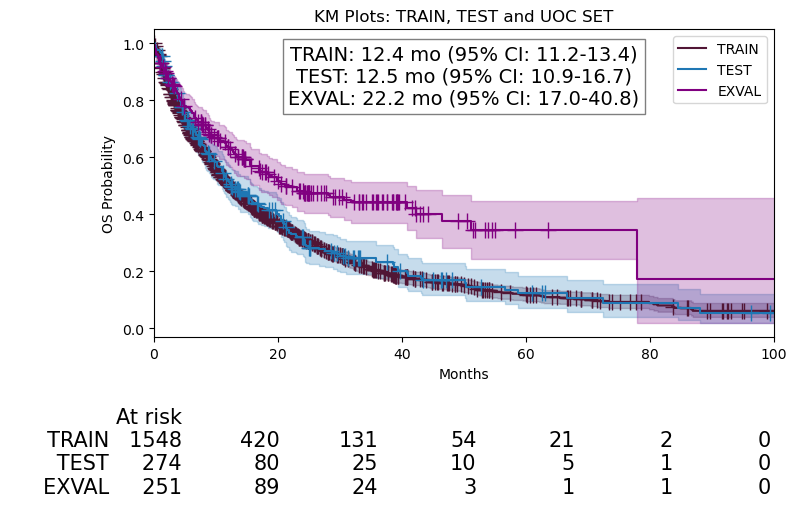

In [22]:
# Define the three subsets
outcomes = pd.read_csv("data/outcomes.csv")
merged = pd.merge(rwd, outcomes, on="Subject", suffixes=('', '_y'))
train_set = merged[merged['SET'] == 'TRAIN']
test_set = merged[merged['SET'] == 'TEST']
uoc_set = merged[merged['SET'] == 'EXVAL']

# Plot the combined Kaplan-Meier curve for OS with median annotations
plot_km_combined('OS', train_set, test_set, uoc_set, 'KM Plots: TRAIN, TEST and UOC SET')